In [101]:
import pandas as pd
import xarray as xr
import numpy as np
import datetime
import re
import copernicusmarine as cm
import pickle

from src.data.matchups import match_up, dms_to_decimal, select_valid_data, radius_weighted_average, average
from matplotlib import pyplot as plt
from pathlib import Path
from difflib import get_close_matches
from tqdm import tqdm

LAT, LON, TIME = 'lat', 'lon', 'time'

p_pro = Path('../../../data/processed/PSEUDO-NITZSCHIA/')
p_pro.mkdir(parents=True, exist_ok=True)

copernicus_product_id = 'cmems_obs-oc_med_bgc-reflectance_nrt_l3-olci-300m_P1D'   # It's OLCI product with 300m resolution
copernicus_product_id = 'cmems_obs-oc_med_bgc-reflectance_my_l3-olci-300m_P1D'

vars_rename = {'RRS400': 400, 'RRS412_5': 412, 'RRS442_5': 442, 'RRS490': 490, 'RRS510': 510, 'RRS560':560, 'RRS620': 620, 'RRS665': 665, 
               'RRS673_75': 673, 'RRS681_25': 681, 'RRS708_75': 708, 'RRS778_75': 778, 'RRS865': 865}

In [102]:
# Data preparation
data = pd.read_excel('../../../data/raw/PSEUDO-NITZSCHIA/PSEUDO-NITZSCHIA EXT FROM IRTA FOR PETRIMED.xlsx', skiprows=2, engine='openpyxl')
data = data.dropna(axis=1, how='all')
data = data.dropna(axis=0, how='all')
data = data.rename(columns={"LAT": LAT, "LONG": LON, "DATE TIME": TIME})

In [103]:
data.head()

,SAMPLING STATION,time,Pseudo-nitzschia (cells/L),lat,lon
0,ARENYS,2020-01-04 16:00:00,0.0,"41°34'45.04""N","2°33'57.61""E"
1,ARENYS,2020-01-12 16:15:00,80.0,"41°34'45.04""N","2°33'57.61""E"
2,ARENYS,2020-01-19 12:15:00,0.0,"41°34'45.04""N","2°33'57.61""E"
3,ARENYS,2020-01-25 16:35:00,0.0,"41°34'45.04""N","2°33'57.61""E"
4,ARENYS,2020-02-01 11:25:00,0.0,"41°34'45.04""N","2°33'57.61""E"


In [104]:
data[LAT] = data[LAT].apply(dms_to_decimal)
data[LON] = data[LON].apply(dms_to_decimal)

In [105]:
ids = data.index
lats = data[LAT]
lons = data[LON]
times = data[TIME]
print(len(times))

2086


In [108]:
np.sort(times)

array(['2020-01-04T11:05:00.000000000', '2020-01-04T12:25:00.000000000',
       '2020-01-04T16:00:00.000000000', ...,
       '2025-08-04T09:45:00.000000000', '2025-08-04T09:47:00.000000000',
       '2025-08-05T00:00:00.000000000'], dtype='datetime64[ns]')

In [37]:
rrs = cm.open_dataset(dataset_id = copernicus_product_id)

INFO - 2025-10-15T18:56:06Z - Selected dataset version: "202211"
INFO - 2025-10-15T18:56:06Z - Selected dataset part: "default"


In [38]:
rrs = rrs.rename({'latitude': LAT, 'longitude': LON}).sortby(LAT).sortby(LON)

In [39]:
match_ups = match_up(ids, lats, lons, times, rrs)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2086/2086 [00:29<00:00, 69.95it/s]


In [40]:
matchups_ds = xr.concat(match_ups,  dim='Id')

In [43]:
matchups_ds.to_netcdf(p_pro / 'matchups.nc')

In [6]:
# Load back, preprocess and create dataset

In [7]:
ds = xr.load_dataset(p_pro / 'matchups.nc')
ds = ds.rename_vars(vars_rename)
ds = ds[list(vars_rename.values())]

In [8]:
# ds = ds.mean(dim='time')

In [9]:
cube_dimension = ds.sizes[LON] * ds.sizes[LAT]* ds.sizes[TIME]
cube_dimension

4725

In [10]:
lats = set(ds.lat.mean(axis=1).values)

lats_indx = {l: ds.lat.mean(axis=1) == l for l in lats}
lats_groups = {l: ds.sel(Id=ind) for l, ind in lats_indx.items()}
max_coverage = {l: (~ds_.mean(dim='Id').isnull()).sum()[400].values/cube_dimension for l, ds_ in lats_groups.items()}

In [11]:
max_coverage

{40.835526: 0.8643386243386243,
 41.57852: 0.5102645502645503,
 42.05133: 0.5257142857142857,
 40.878757: 0.5100529100529101,
 41.257004: 0.48232804232804233,
 40.554543: 0.4526984126984127,
 40.549137: 0.5828571428571429,
 41.475853: 0.5032804232804233,
 41.846: 0.4721693121693122,
 41.48936: 0.5085714285714286,
 42.259373: 0.39915343915343915,
 41.232693: 0.49206349206349204,
 40.630188: 0.555978835978836,
 41.21108: 0.5037037037037037}

In [12]:
# select valid data relative to the maximum information possible
threshold = 0.4
valid_data = [select_valid_data(group, max_coverage[l] * threshold) for l, group in lats_groups.items()]
hq_data = [select_valid_data(group, max_coverage[l] * 0.9) for l, group in lats_groups.items()]
ds_valid = xr.concat(valid_data, dim='Id')
ds_hq = xr.concat(hq_data, dim='Id')

In [13]:
ds_avg = average(ds_valid)
ds_w_avg = radius_weighted_average(ds_valid)

In [14]:
ds_avg = ds_avg.to_dataframe()
ds_w_avg = ds_w_avg.to_dataframe()

In [15]:
# Check it is paired (by date)

In [49]:
import numpy as np

def day_to_circle_x(day, period=365):
    angle = 2 * np.pi * day / period
    return np.cos(angle)

def day_to_circle_y(day, period=365):
    angle = 2 * np.pi * day / period
    return np.sin(angle)

In [51]:
dates = ds_avg['time']
day_of_year = dates.dt.dayofyear
ds_avg['x_day'] = day_of_year.apply(day_to_circle_x).values
ds_avg['y_day'] = day_of_year.apply(day_to_circle_y).values
ds_w_avg['x_day'] = ds_avg['x_day']
ds_w_avg['y_day'] = ds_avg['y_day']

In [16]:
print(ds_avg.loc[537])
print(data.loc[537])

400                0.007092
412                0.006624
442                0.006511
490                0.006234
510                0.004847
560                0.002951
620                0.000397
665                0.000131
673                0.000105
681                0.000092
708                0.000079
778                0.000087
865                0.000026
lat               40.835526
lon                 0.82448
time    2023-07-31 00:00:00
Name: 537, dtype: object
SAMPLING STATION                           JAULAS
time                          2023-07-31 00:00:00
Pseudo-nitzschia (cells/L)                 1040.0
lat                                     40.834417
lon                                      0.826017
Name: 537, dtype: object


In [84]:
x = ds_w_avg[list(vars_rename.values()) + ['lat', 'lon', 'x_day', 'y_day']]
y = data[['Pseudo-nitzschia (cells/L)']].loc[x.index]
x[list(vars_rename.values())] = np.log(x[list(vars_rename.values())] )
x = x.fillna(x.min(numeric_only=True))

C:\Users\sheic\PycharmProjects\pigment-retrieval-from-olci\venv\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
C:\Users\sheic\AppData\Local\Temp\ipykernel_12100\3579409494.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[list(vars_rename.values())] = np.log(x[list(vars_rename.values())] )


In [85]:
from src.data.data_utils import stratified_split_multidim_kmeans

n_splits = 1
r = 42
test_size = 0.2
clusters = 5

split = stratified_split_multidim_kmeans(x, y, n_splits=n_splits, clusters=clusters, test_size=test_size,
                                         random_state=r)

for i, (id_train, id_test) in enumerate(split):
    x_train, y_train = x.iloc[id_train, :].copy(), y.iloc[id_train, :].copy()
    x_test, y_test = x.iloc[id_test, :].copy(), y.iloc[id_test, :].copy()

In [86]:
from src.models.sklearn_models import XGBModel
from src.data.data_utils import augment_data

hp_sp = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [None, 3, 4, 5, 6],                  
    "eta": [0.025, 0.05, 0.1, 1],              
    "colsample_bytree": [0.6, 0.75, 0.8],       
    "min_child_weight": [4, 5, 6],               
    "subsample": [0.5, 0.6, 0.75],               
    "gamma": [0.5, 0.7],             
    "lambda": [1, 2],   
    "alpha": [0.5, 1.0],              
    "booster": ["gbtree"],
    "tree_method": ["auto"]
  }
xgb = XGBModel()

In [87]:
x_train_aug, y_train_aug = augment_data(x_train, y_train, replicate=1)
hp, loss = xgb.hyperparameter_search(hp_sp, x_train_aug, y_train_aug)

In [88]:
xgb.build_model(**hp)
xgb.fit(x_train_aug, y_train_aug)

In [95]:
py = xgb.predict(x_test)

In [96]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

mets = {'r2': r2_score, 'mae': mean_absolute_error, 'mape': mean_absolute_percentage_error, 'mse': mean_squared_error}

mets_res = {m_name: m_(y_test, py) for m_name, m_ in mets.items()}

In [97]:
pd.DataFrame({'true': y_test.T.values[0], 'pred': py})

,true,pred
0,3206.0,61178.066406
1,1377.0,49854.609375
2,2295.0,18213.634766
3,17862.0,2263.150146
4,920.0,11390.333984
...,...,...
95,1836.0,15820.874023
96,4590.0,-69.552856
97,19278.0,131370.828125
98,20196.0,146887.890625


In [98]:
loss

0.47070221106211346

In [99]:
mets_res

{'r2': -0.7310315370559692,
 'mae': 37907.25390625,
 'mape': 1.1891482137188106e+19,
 'mse': 5200853504.0}

In [100]:
mets_res

{'r2': -0.7310315370559692,
 'mae': 37907.25390625,
 'mape': 1.1891482137188106e+19,
 'mse': 5200853504.0}

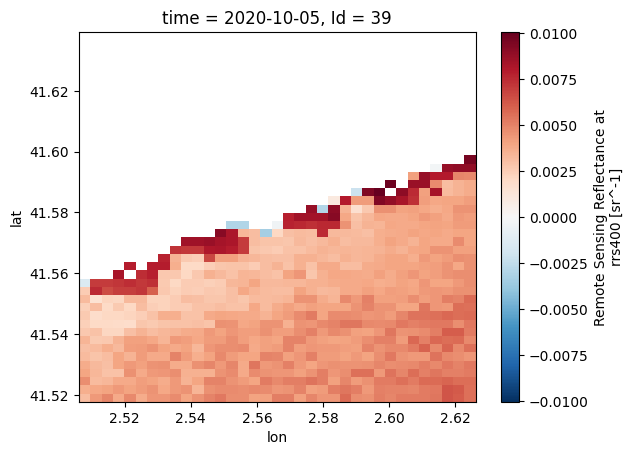

In [108]:
ds_hq.isel(Id=0, time=2)[400].plot()